In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import os
import librosa
import librosa.display
from tabulate import tabulate

In [2]:
DATA_PATH = r"C:\Users\renee\Desktop\FYP\mosei_raw.pkl"

with open(DATA_PATH, "rb") as f:
    data = pickle.load(f)

In [3]:
splits = {}
for split in ["train", "valid", "test"]:
    splits[split] = data[split]["audio"].shape[0]
print("Samples per split:", splits)

total_samples = sum(splits.values())
print("Total samples:", total_samples)

Samples per split: {'train': 16327, 'valid': 1871, 'test': 4662}
Total samples: 22860


In [4]:
for split in ["train", "valid", "test"]:
    audio = data[split]["audio"]
    labels = data[split]["labels"]
    ids = data[split]["id"]

    print(f"\n=== {split.upper()} ===")
    print("Audio shape:", audio.shape)
    print("Labels shape:", labels.shape)
    print("Total samples:", audio.shape[0])


=== TRAIN ===
Audio shape: (16327, 50, 74)
Labels shape: (16327, 1, 7)
Total samples: 16327

=== VALID ===
Audio shape: (1871, 50, 74)
Labels shape: (1871, 1, 7)
Total samples: 1871

=== TEST ===
Audio shape: (4662, 50, 74)
Labels shape: (4662, 1, 7)
Total samples: 4662


In [5]:
for split in ["train", "valid", "test"]:
    audio = data[split]["audio"]
    labels = data[split]["labels"]
    ids = data[split]["id"]

    print(f"\n=== {split.upper()} ===")
    print("Audio shape:", audio.shape)
    print("Labels shape:", labels.shape)
    print("Total samples:", audio.shape[0])



=== TRAIN ===
Audio shape: (16327, 50, 74)
Labels shape: (16327, 1, 7)
Total samples: 16327

=== VALID ===
Audio shape: (1871, 50, 74)
Labels shape: (1871, 1, 7)
Total samples: 1871

=== TEST ===
Audio shape: (4662, 50, 74)
Labels shape: (4662, 1, 7)
Total samples: 4662


In [6]:
all_ids = set(data["train"]["id"]) | set(data["valid"]["id"]) | set(data["test"]["id"])
video_ids = set([i.split('[')[0] for i in all_ids])
print("Distinct video IDs:", len(video_ids))

Distinct video IDs: 3225


In [7]:
ids = data["train"]["id"]
print("Head 5 IDs:", ids[:5])

Head 5 IDs: ['-3g5yACwYnA[0]', '-3g5yACwYnA[1]', '-3g5yACwYnA[2]', '-3g5yACwYnA[3]', '-3g5yACwYnA[4]']


In [8]:
labels = data["train"]["labels"]

print("Head 5 labels:")
for i in range(5):
    print(f"Sample {i+1}: {labels[i].squeeze().tolist()}")

Head 5 labels:
Sample 1: [1.0, 0.6666666865348816, 0.6666666865348816, 0.0, 0.0, 0.0, 0.6666666865348816]
Sample 2: [0.6666666865348816, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Sample 3: [0.0, 0.6666666865348816, 0.6666666865348816, 0.0, 0.0, 0.0, 0.3333333432674408]
Sample 4: [0.0, 0.3333333432674408, 0.3333333432674408, 0.0, 0.0, 0.0, 0.0]
Sample 5: [1.0, 0.6666666865348816, 0.0, 0.0, 0.0, 0.0, 0.0]


In [9]:
def build_df(split):
    labels = data[split]["labels"].squeeze()
    ids = data[split]["id"]
    df = pd.DataFrame(labels, columns=[
        "sentiment", "happy", "sad", "angry", "fear", "disgust", "surprise"
    ])
    df["id"] = ids
    df["split"] = split
    df["sentiment_class"] = df["sentiment"].apply(
        lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral")
    )
    return df

train_df = build_df("train")
valid_df = build_df("valid")
test_df  = build_df("test")

label_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

print(label_df.head(10))
print("Total samples:", len(label_df))
print(label_df["split"].value_counts())

   sentiment     happy       sad  angry  fear  disgust  surprise  \
0   1.000000  0.666667  0.666667    0.0   0.0      0.0  0.666667   
1   0.666667  0.000000  0.000000    0.0   0.0      0.0  0.000000   
2   0.000000  0.666667  0.666667    0.0   0.0      0.0  0.333333   
3   0.000000  0.333333  0.333333    0.0   0.0      0.0  0.000000   
4   1.000000  0.666667  0.000000    0.0   0.0      0.0  0.000000   
5   0.666667  0.000000  0.666667    0.0   0.0      0.0  0.333333   
6   0.333333  1.666667  0.000000    0.0   0.0      0.0  0.000000   
7   1.000000  2.333333  0.000000    0.0   0.0      0.0  0.000000   
8   0.000000  1.666667  0.000000    0.0   0.0      0.0  0.000000   
9   0.000000  0.000000  0.000000    0.0   0.0      0.0  0.000000   

               id  split sentiment_class  
0  -3g5yACwYnA[0]  train        Positive  
1  -3g5yACwYnA[1]  train        Positive  
2  -3g5yACwYnA[2]  train         Neutral  
3  -3g5yACwYnA[3]  train         Neutral  
4  -3g5yACwYnA[4]  train        Posi

In [10]:
label_df.to_csv(r"C:\Users\renee\Desktop\FYP\label_data.csv", index=False)

In [11]:
label_df

,sentiment,happy,sad,angry,fear,disgust,surprise,id,split,sentiment_class
0,1.000000,0.666667,0.666667,0.0,0.000000,0.0,0.666667,-3g5yACwYnA[0],train,Positive
1,0.666667,0.000000,0.000000,0.0,0.000000,0.0,0.000000,-3g5yACwYnA[1],train,Positive
2,0.000000,0.666667,0.666667,0.0,0.000000,0.0,0.333333,-3g5yACwYnA[2],train,Neutral
3,0.000000,0.333333,0.333333,0.0,0.000000,0.0,0.000000,-3g5yACwYnA[3],train,Neutral
4,1.000000,0.666667,0.000000,0.0,0.000000,0.0,0.000000,-3g5yACwYnA[4],train,Positive
...,...,...,...,...,...,...,...,...,...,...
22855,-0.333333,0.333333,0.000000,0.0,0.666667,0.0,0.000000,zhNksSReaQk[7],test,Negative
22856,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,zhNksSReaQk[8],test,Neutral
22857,0.000000,0.666667,0.000000,0.0,0.000000,0.0,0.000000,zhNksSReaQk[9],test,Neutral
22858,1.666667,2.333333,0.000000,0.0,0.000000,0.0,0.000000,zvZd3V5D5Ik[0],test,Positive


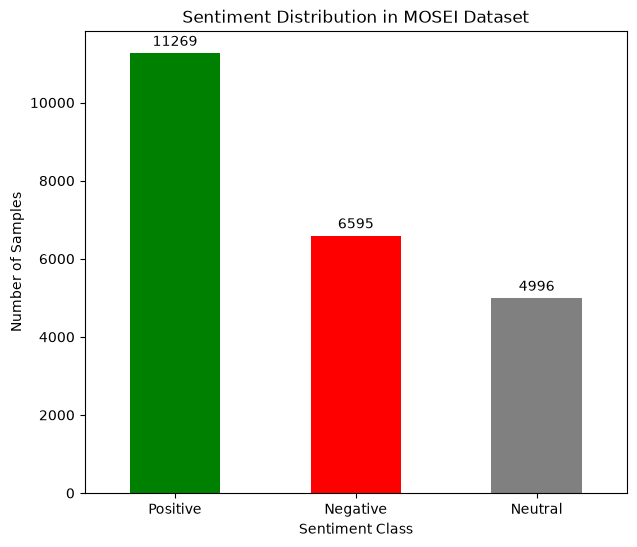

In [12]:
sentiment_counts = label_df["sentiment_class"].value_counts()

plt.figure(figsize=(7,6))
sentiment_counts.plot(kind="bar", color=["green", "red", "gray"])

plt.title("Sentiment Distribution in MOSEI Dataset")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

for i, count in enumerate(sentiment_counts):
    plt.text(i, count + 100, str(count), ha="center", va="bottom", fontsize=10)
plt.show()

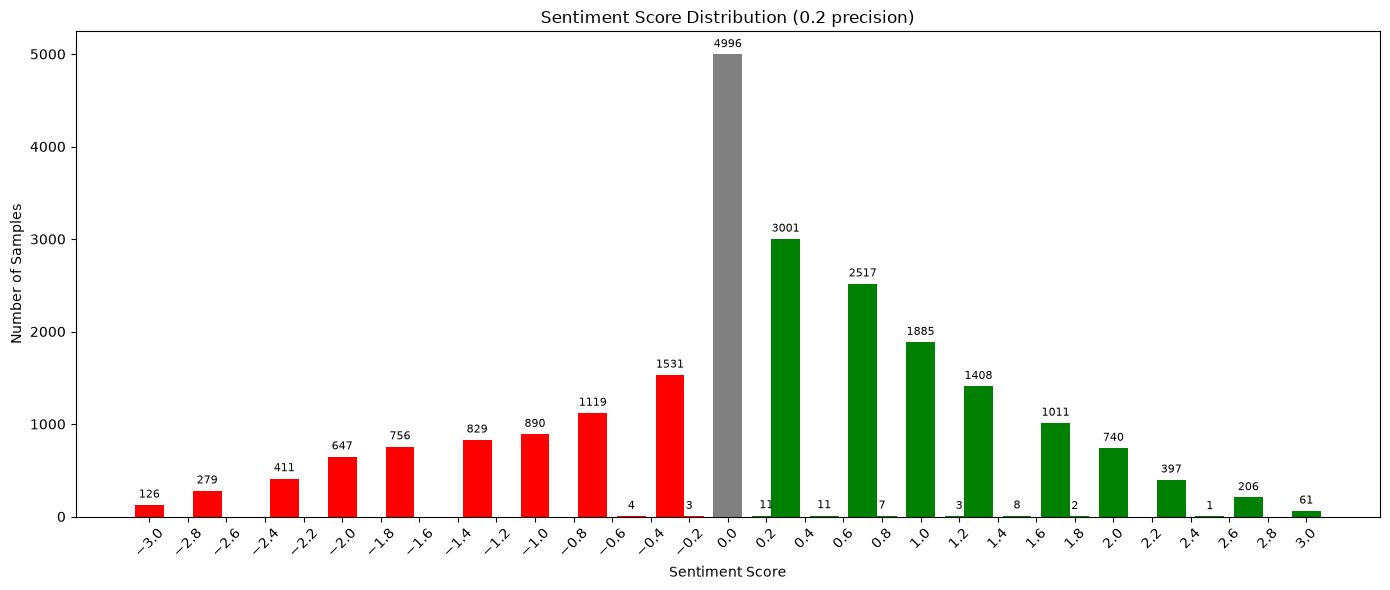

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Round scores to nearest 0.2 for finer bins
label_df["score_bin"] = label_df["sentiment"].round(1)   # or .round(2) if you want 0.2 precision

# Count frequency per bin
score_counts = label_df["score_bin"].value_counts().sort_index()

# Assign colors by sentiment class
colors = ["red" if s < 0 else "gray" if s == 0 else "green" for s in score_counts.index]

plt.figure(figsize=(14,6))

# Make bars narrower (width=0.15) so they don’t overlap
bars = plt.bar(score_counts.index, score_counts.values, 
               width=0.15, color=colors, align="center")

plt.title("Sentiment Score Distribution (0.2 precision)")
plt.xlabel("Sentiment Score")
plt.ylabel("Number of Samples")

# Add labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50,
             str(height), ha="center", va="bottom", fontsize=8)

# Adjust x ticks for clarity
plt.xticks(np.arange(min(score_counts.index), max(score_counts.index)+0.2, 0.2), rotation=45)

plt.tight_layout()
plt.show()


In [14]:
print(label_df["sentiment"].describe())


count    22860.000000
mean         0.149169
std          1.114515
min         -3.000000
25%         -0.333333
50%          0.000000
75%          1.000000
max          3.000000
Name: sentiment, dtype: float64


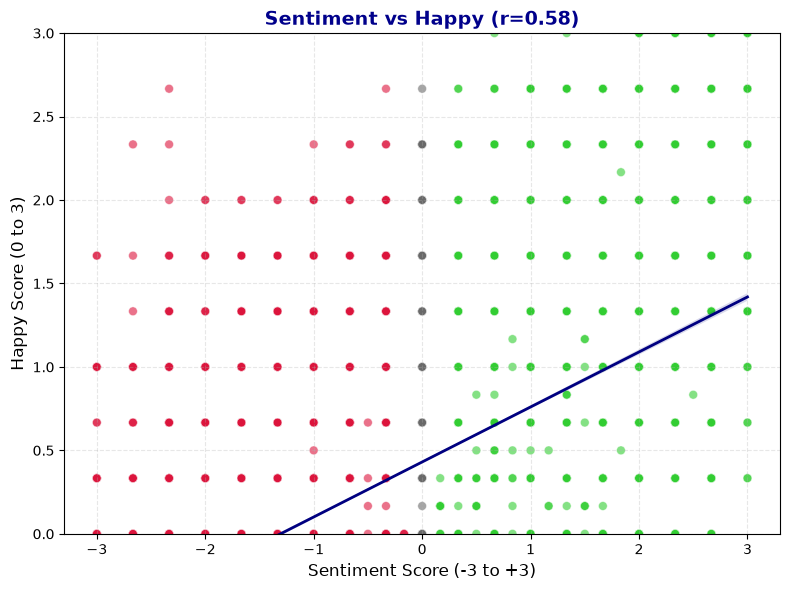

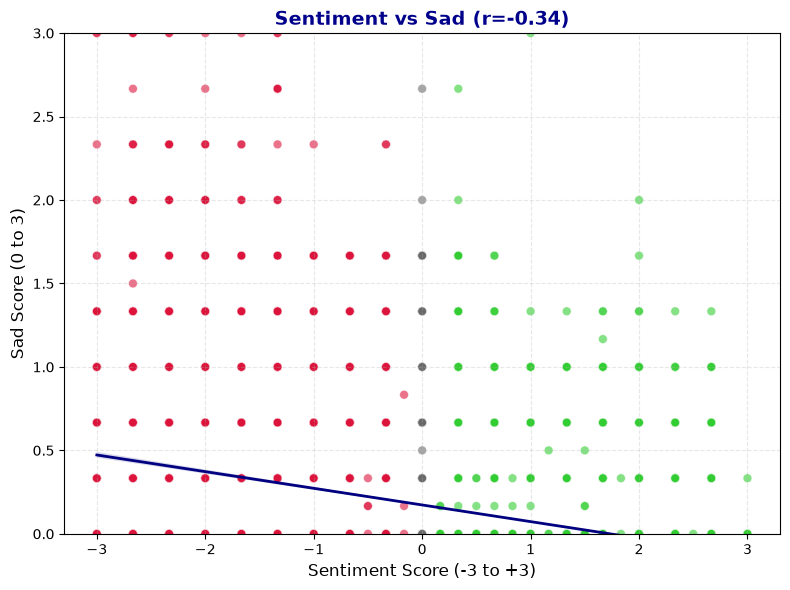

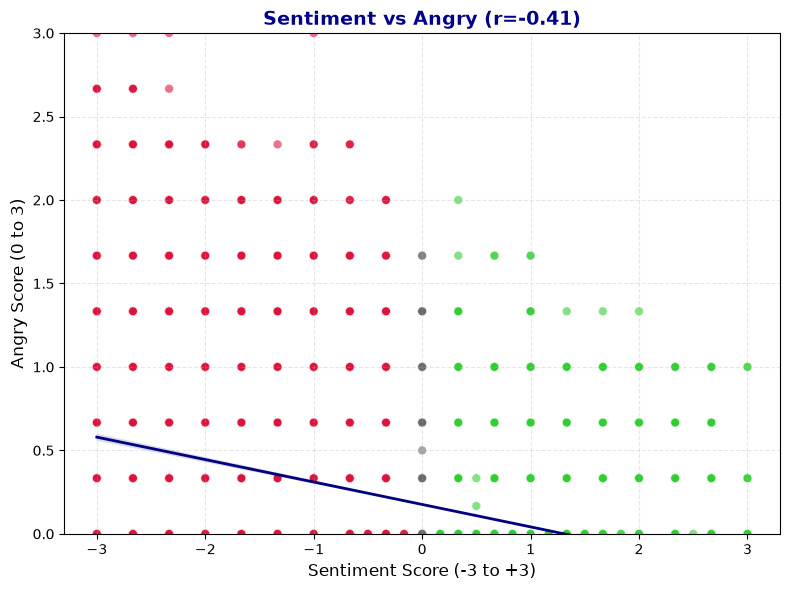

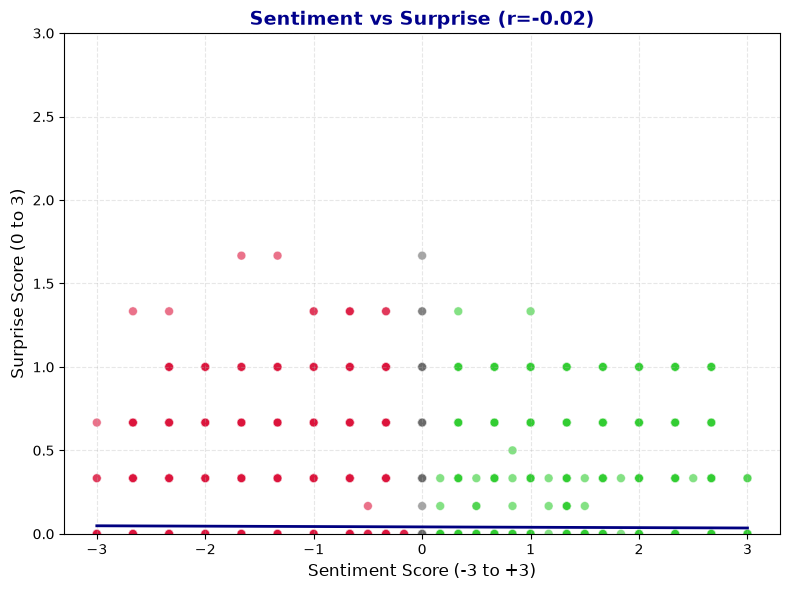

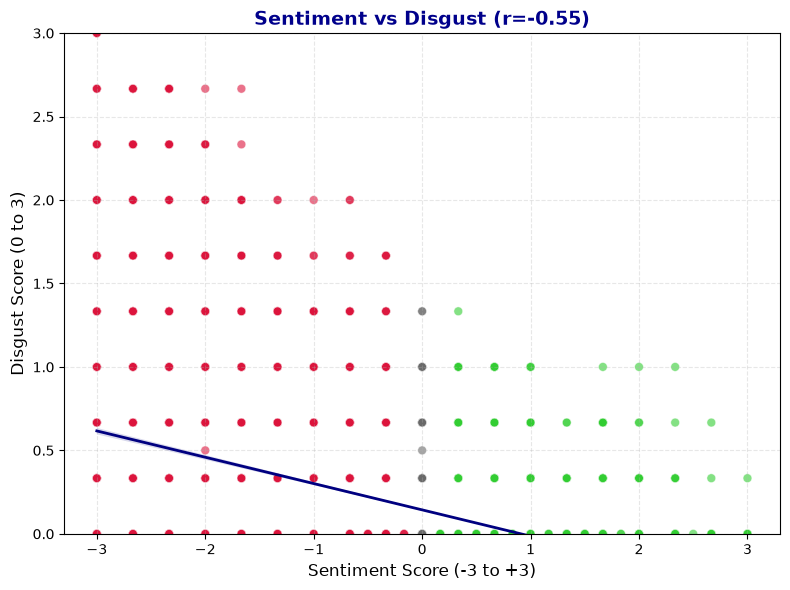

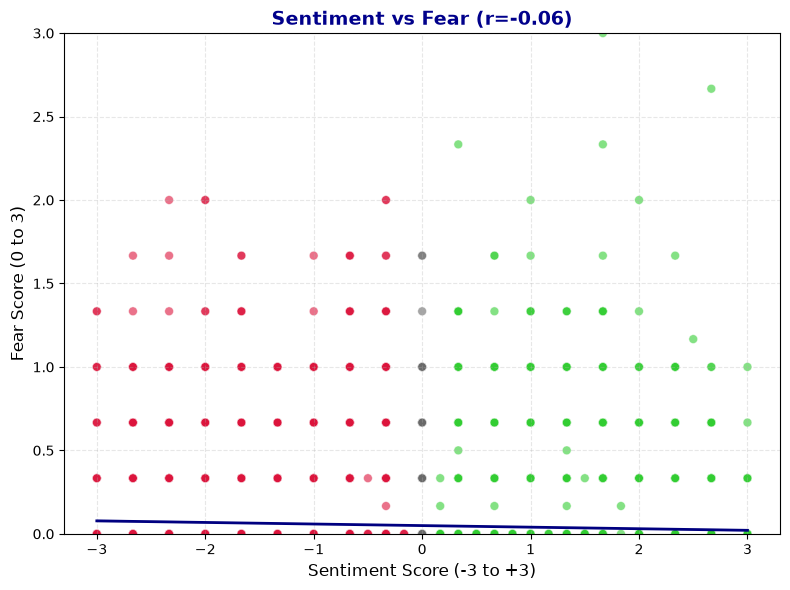

In [15]:
emotions = ["happy", "sad", "angry", "surprise", "disgust", "fear"]

for emo in emotions:
    plt.figure(figsize=(8,6))
    

    plt.scatter(label_df["sentiment"], label_df[emo],
                c=label_df["sentiment_class"].map({
                    "Positive":"limegreen",
                    "Negative":"crimson",
                    "Neutral":"dimgray"}),
                alpha=0.6, s=40, marker="o", edgecolors="white", linewidth=0.5)
    
    # 回歸線
    sns.regplot(x="sentiment", y=emo, data=label_df,
                scatter=False, color="navy", line_kws={"lw":2})
    
    # 計算 Pearson correlation
    corr = label_df["sentiment"].corr(label_df[emo])
    
    # 美化標題
    plt.title(f"Sentiment vs {emo.capitalize()} (r={corr:.2f})",
              fontsize=14, fontweight="bold", color="darkblue")
    
    plt.xlabel("Sentiment Score (-3 to +3)", fontsize=12)
    plt.ylabel(f"{emo.capitalize()} Score (0 to 3)", fontsize=12)
    plt.ylim(0, 3)
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()


In [16]:
file_path = r"C:\Users\renee\Desktop\FYP\CMU_MOSEI_COVAREP.csd"
with h5py.File(file_path, "r") as f:
    covarep_group = f["COVAREP"]["data"]
    sample_ids = list(covarep_group.keys())
    
    # 查看第一個 sample 嘅結構
    first_sample = covarep_group[sample_ids[0]]
    print("Keys inside first sample:", list(first_sample.keys()))


Keys inside first sample: ['features', 'intervals']


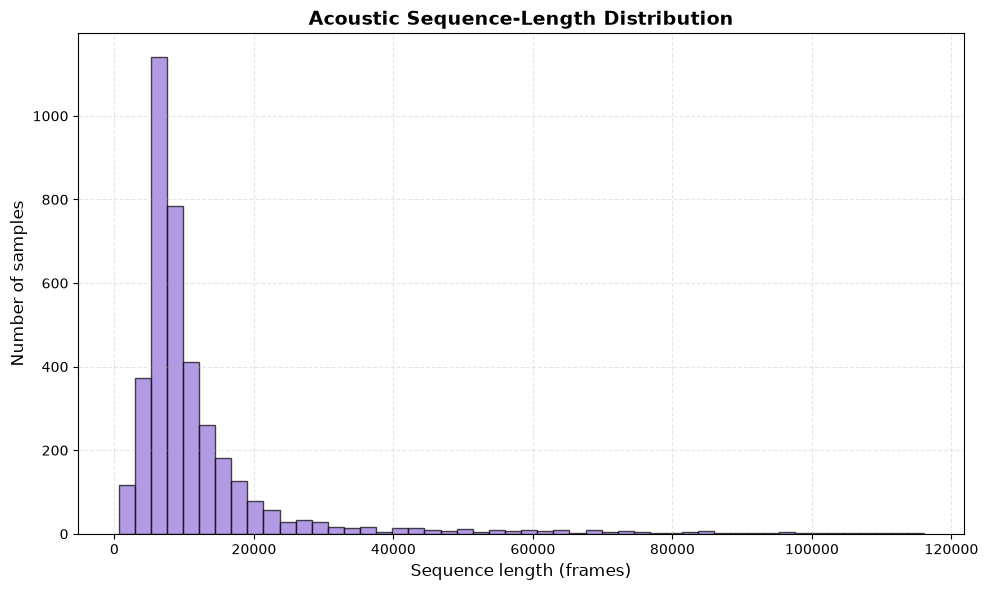

Min length: 597
Max length: 116016
Mean length: 12113.83315954119
Median length: 8211.0


In [17]:
file_path = r"C:\Users\renee\Desktop\FYP\CMU_MOSEI_COVAREP.csd"
with h5py.File(file_path, "r") as f:
    covarep_group = f["COVAREP"]["data"]
    sample_ids = list(covarep_group.keys())
    
    lengths = [covarep_group[sid]["features"].shape[0] for sid in sample_ids]


plt.figure(figsize=(10,6))
plt.hist(lengths, bins=50, color="mediumpurple", edgecolor="black", alpha=0.7)
plt.title("Acoustic Sequence-Length Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Sequence length (frames)", fontsize=12)
plt.ylabel("Number of samples", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


print("Min length:", np.min(lengths))
print("Max length:", np.max(lengths))
print("Mean length:", np.mean(lengths))
print("Median length:", np.median(lengths))


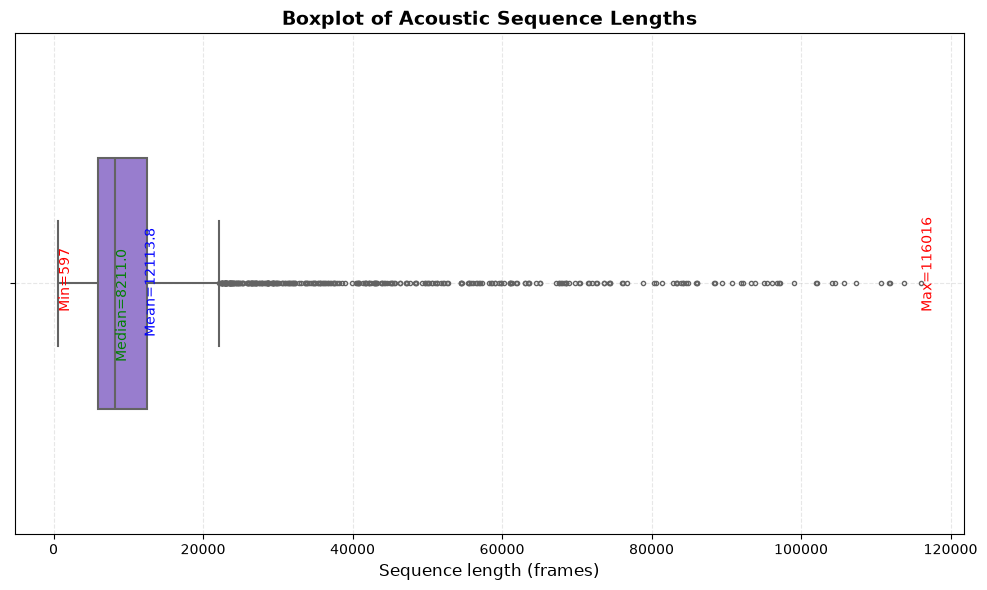

In [18]:
min_len = np.min(lengths)
max_len = np.max(lengths)
mean_len = np.mean(lengths)
median_len = np.median(lengths)

plt.figure(figsize=(10,6))
sns.boxplot(x=lengths, color="mediumpurple", width=0.5, fliersize=3, linewidth=1.5)

plt.title("Boxplot of Acoustic Sequence Lengths", fontsize=14, fontweight="bold")
plt.xlabel("Sequence length (frames)", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")


plt.text(min_len, 0.05, f"Min={min_len}", rotation=90, color="red")
plt.text(max_len, 0.05, f"Max={max_len}", rotation=90, color="red")
plt.text(mean_len, 0.1, f"Mean={mean_len:.1f}", rotation=90, color="blue")
plt.text(median_len, 0.15, f"Median={median_len}", rotation=90, color="green")

plt.tight_layout()
plt.show()


In [19]:
import h5py
import numpy as np

file_path = r"C:\Users\renee\Desktop\FYP\CMU_MOSEI_COVAREP.csd"

total_frames = 0
bad_frames = 0
total_samples = 0
bad_samples = 0
nan_count = 0
inf_count = 0

with h5py.File(file_path, "r") as f:
    covarep_group = f["COVAREP"]["data"]
    for sid in covarep_group.keys():
        features = covarep_group[sid]["features"][:]
        total_samples += 1
        total_frames += features.shape[0]

        nan_count += np.isnan(features).sum()
        inf_count += np.isinf(features).sum()

        frame_has_inf = np.any(np.isinf(features), axis=1)
        bad_frames += frame_has_inf.sum()

        if frame_has_inf.any() or np.any(np.isnan(features)):
            bad_samples += 1

print("Total samples:", total_samples)
print("Total frames:", total_frames)
print("Average frames per sample:", f"{total_frames / total_samples:.2f}")
print("Total NaN values:", nan_count)
print("Total Inf values:", inf_count)
print("Bad frames:", bad_frames)
print("Bad frame percentage:", f"{bad_frames / total_frames * 100:.2f}%")
print("Bad samples:", bad_samples)
print("Bad sample percentage:", f"{bad_samples / total_samples * 100:.2f}%")

Total samples: 3836
Total frames: 46468664
Average frames per sample: 12113.83
Total NaN values: 0
Total Inf values: 11430
Bad frames: 11430
Bad frame percentage: 0.02%
Bad samples: 2707
Bad sample percentage: 70.57%


In [20]:
labels_path = r"C:\Users\renee\Desktop\FYP\CMU_MOSEI_Labels.csd"
f = h5py.File(labels_path, "r")
labels_group = f["All Labels"]["data"]

emotion_labels = ["Sentiment", "Happy", "Sad", "Angry", "Surprise", "Disgust", "Fear"]

results = {}

max_sentiment = None
min_sentiment = None


for sample_id in labels_group.keys():
    features = labels_group[sample_id]["features"][0]

    if max_sentiment is None or features[0] > max_sentiment[1]:
        max_sentiment = (sample_id, features[0])
    if min_sentiment is None or features[0] < min_sentiment[1]:
        min_sentiment = (sample_id, features[0])

    # 其他情緒：取最大值
    for i, emo in enumerate(emotion_labels[1:], start=1):
        if emo not in results or features[i] > results[emo][1]:
            results[emo] = (sample_id, features[i])

final_results = {
    "Positive": max_sentiment,
    "Negative": min_sentiment
}
final_results.update(results)

for emo, (sample_id, value) in final_results.items():
    print(f"{emo}: sample_id = {sample_id}, value = {value:.2f}")


Positive: sample_id = 210618, value = 3.00
Negative: sample_id = 7oFimEZJQ_A, value = -3.00
Happy: sample_id = 6-0bcijTR8k, value = 3.00
Sad: sample_id = zrFZAofNGi4, value = 3.00
Angry: sample_id = XQOUZhWI1B0, value = 3.00
Surprise: sample_id = qmMSumMloAs, value = 1.67
Disgust: sample_id = 275248, value = 2.00
Fear: sample_id = jjbOD6u7V34, value = 1.67


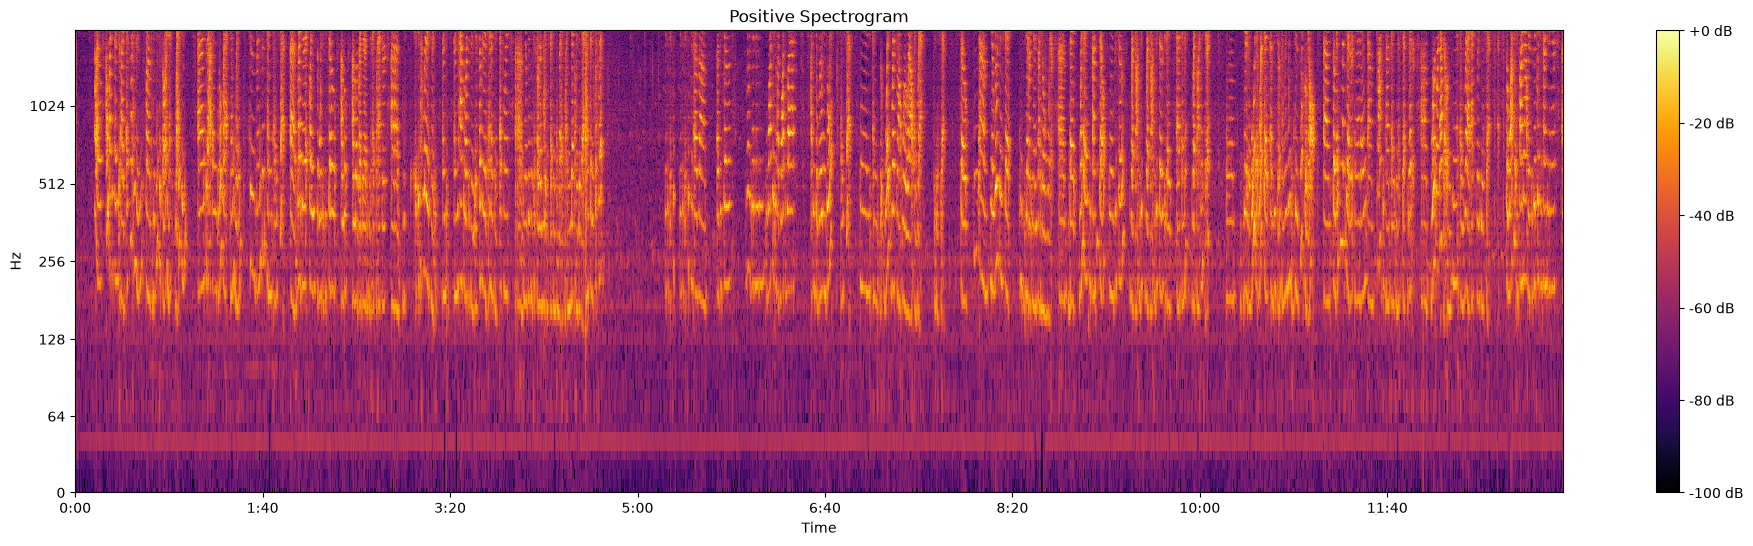

Positive: min = -141.40, max = 0.00, mean = -62.59


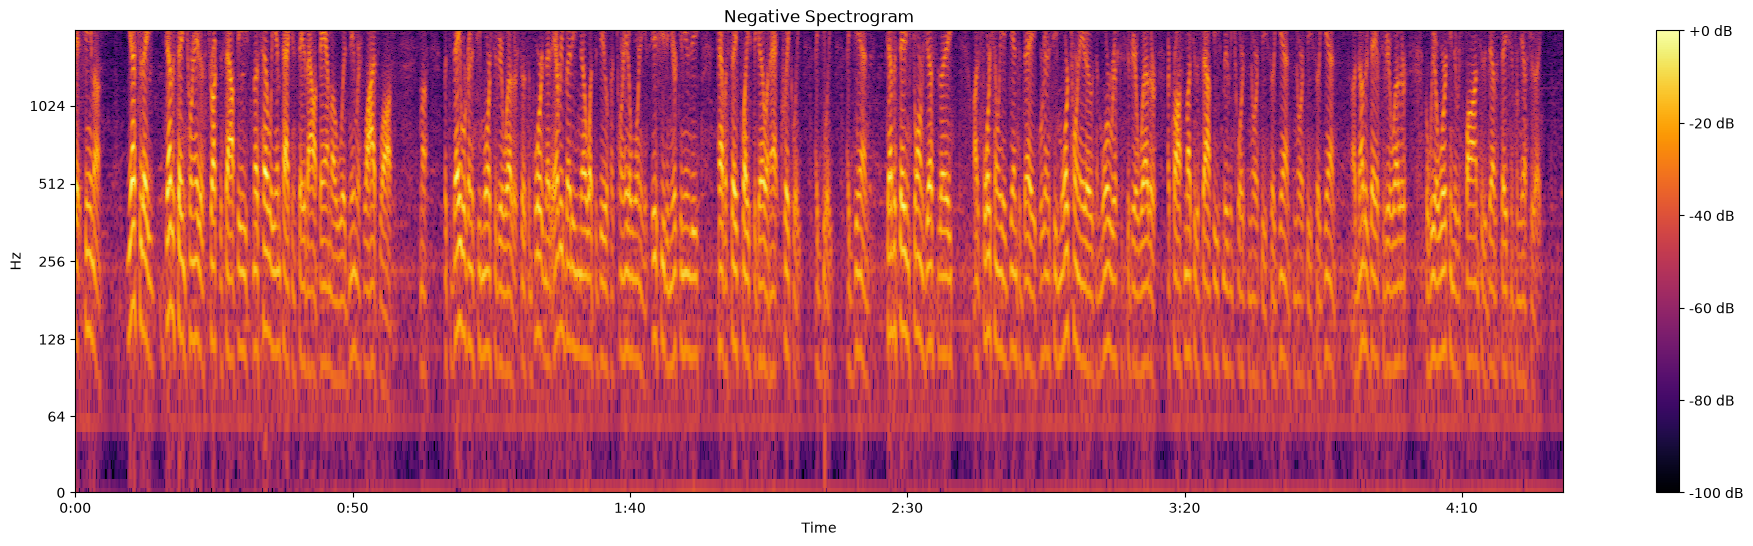

Negative: min = -145.32, max = 0.00, mean = -68.59


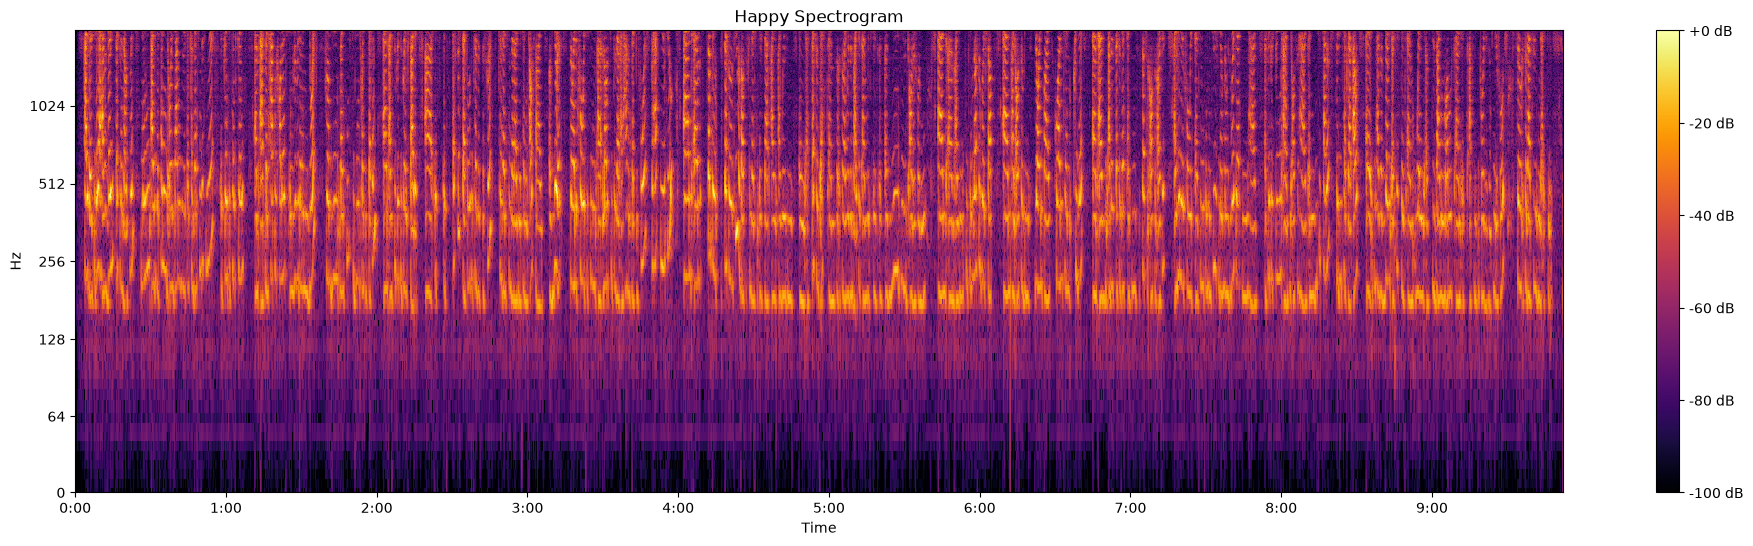

Happy: min = -142.46, max = 0.00, mean = -69.63


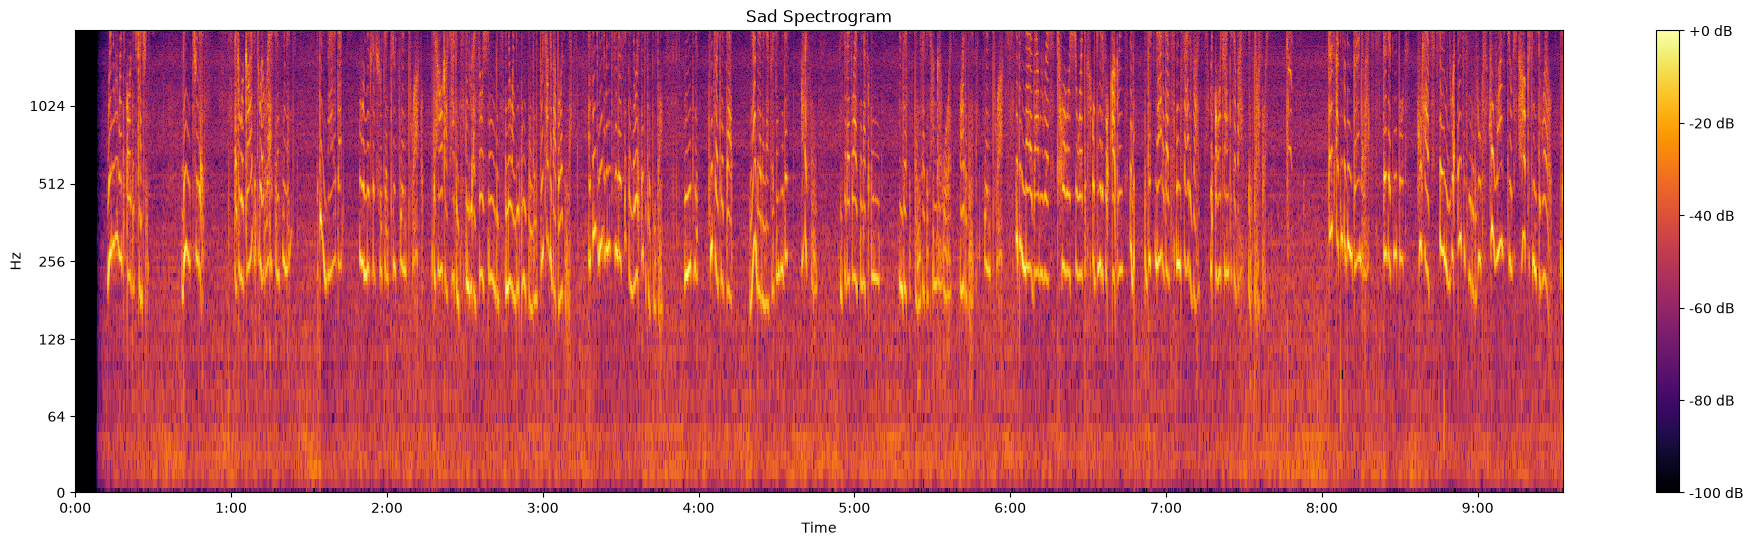

Sad: min = -139.33, max = 0.00, mean = -66.66


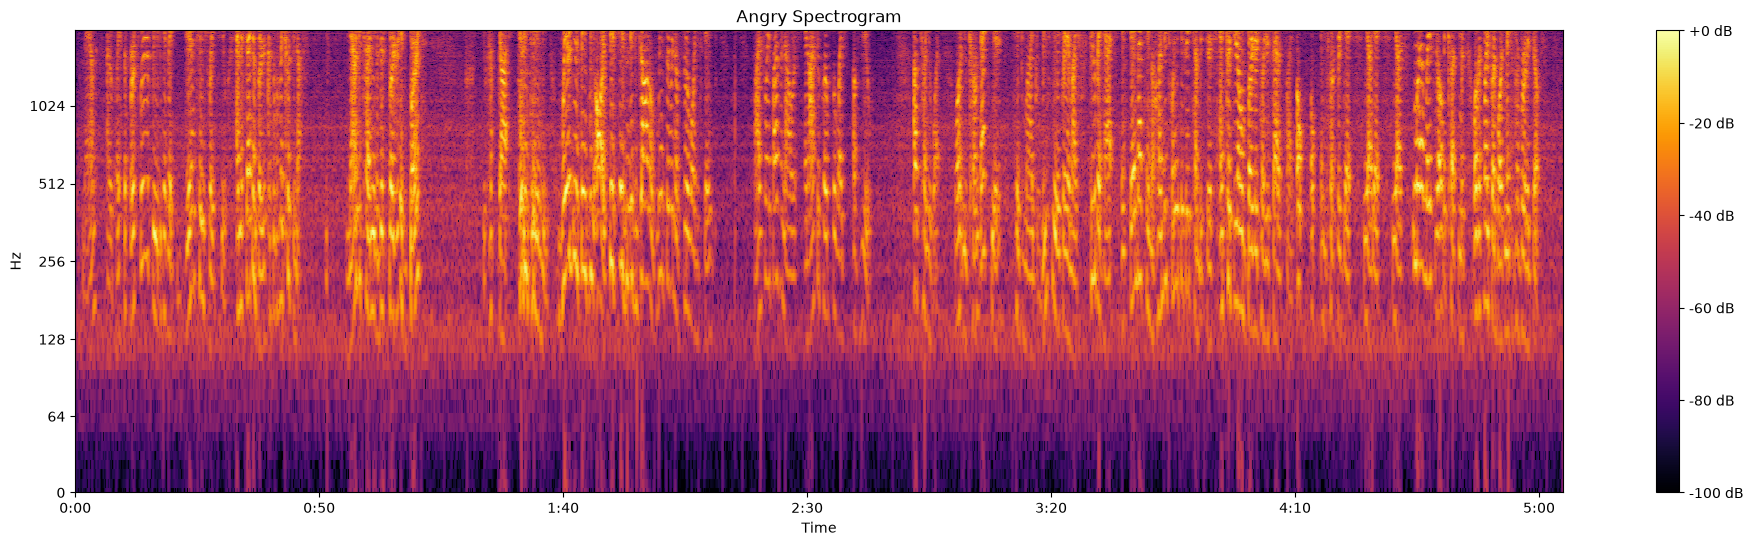

Angry: min = -145.99, max = 0.00, mean = -59.51

    Emotion Min (dB) Max (dB) Mean (dB)
0  Positive  -141.40     0.00    -62.59
1  Negative  -145.32     0.00    -68.59
2     Happy  -142.46     0.00    -69.63
3       Sad  -139.33     0.00    -66.66
4     Angry  -145.99     0.00    -59.51


In [21]:
result = []

sample_ids = {
    "Positive": "210618",
    "Negative": "7oFimEZJQ_A",
    "Happy": "6-0bcijTR8k",
    "Sad": "zrFZAofNGi4",
    "Angry": "XQOUZhWI1B0"
}

Path = r"C:\Users\renee\Desktop\FYP\Raw\Raw\processed"

for emo, vid in sample_ids.items():
    folder = os.path.join(Path, f"{vid}merged.wav")
    y, sr = librosa.load(folder, sr=16000)

    S = librosa.stft(y, n_fft=2048, hop_length=64)

    S_db = librosa.amplitude_to_db(abs(S), ref=np.max, top_db=None)

    min_val = np.min(S_db)  
    max_val = np.max(S_db) 
    mean_val = np.mean(S_db)
    result.append([emo, f"{min_val:.2f}", f"{max_val:.2f}", f"{mean_val:.2f}"])

    plt.figure(figsize=(24, 6))
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="log",
                             cmap="inferno", vmin=-100, vmax=0)  
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"{emo} Spectrogram")
    plt.ylim(0, 2000)
    plt.show()

    print(f"{emo}: min = {min_val:.2f}, max = {max_val:.2f}, mean = {mean_val:.2f}")

df = pd.DataFrame(result, columns=["Emotion", "Min (dB)", "Max (dB)", "Mean (dB)"])
print("")
print(df)


In [22]:
sample_ids = {
    "Positive": "210618",
    "Negative": "7oFimEZJQ_A",
    "Happy": "6-0bcijTR8k",
    "Sad": "zrFZAofNGi4",
    "Angry": "XQOUZhWI1B0"
}

Path = r"C:\Users\renee\Desktop\FYP\Raw\Raw\processed"

bands = [(0,500), (500,1000), (1000,1500), (1500,2000),
         (2000,2500), (2500,3000), (3000,3500), (3500,4000)]

results = []

for emo, vid in sample_ids.items():
    folder = os.path.join(Path, f"{vid}merged.wav")
    y, sr = librosa.load(folder, sr=16000)

    S = librosa.stft(y, n_fft=2048, hop_length=128)
    S_db = librosa.amplitude_to_db(abs(S))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)

    main_freqs = freqs[np.argmax(S_db, axis=0)]

    frame_duration = 128 / sr
    total_duration = len(y) / sr  
    emo_result = {"Emotion": emo}

    for low, high in bands:
        count = np.sum((main_freqs >= low) & (main_freqs < high))
        seconds = count * frame_duration
        percentage = (seconds / total_duration) * 100
        emo_result[f"{low}-{high}Hz (%)"] = f"{percentage:.2f}"

    results.append(emo_result)

df = pd.DataFrame(results)

print(tabulate(df, headers="keys", tablefmt="grid"))


+----+-----------+---------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+
|    | Emotion   |   0-500Hz (%) |   500-1000Hz (%) |   1000-1500Hz (%) |   1500-2000Hz (%) |   2000-2500Hz (%) |   2500-3000Hz (%) |   3000-3500Hz (%) |   3500-4000Hz (%) |
+====+===========+===============+==================+===================+===================+===================+===================+===================+===================+
|  0 | Positive  |         52.55 |            39.59 |              2.56 |              1.91 |              0.46 |              0.5  |              0.41 |              0.27 |
+----+-----------+---------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+
|  1 | Negative  |         74.67 |            22.93 |              0    |              0    |              0.02 |              0.1